# Когортный анализ удержания пользователей

## 1. Цель анализа

Определить когорты с аномальным падением удержания и предложить гипотезу для улучшения retention.

## 2. Данные

- **Источник:** события пользователей (event_time, event_type, user_id)
- **Период:** сентябрь 2020 — февраль 2021
- **Очистка:** удалены дубликаты, дата приведена в формат date
- **Когорта:** общая дата для всех пользователей этой группы (cohort_date)

## 3. SQL-логика расчёта retention

- Определена дата когорты для каждого user_id
- Для каждого события рассчитан day_number = разница в днях между event_date и cohort_date
- Подсчитано количество уникальных пользователей для каждой (когорта, день)
- Рассчитан retention_rate = (active_users / cohort_size) * 100

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cohort_retention.csv',parse_dates=['cohort_date'])

print(df.head())
print(df.info())


  cohort_date  day_number  active_users  retention_rate
0  2020-09-24         0.0          1358          100.00
1  2020-09-24         1.0            68            5.01
2  2020-09-24         2.0            37            2.72
3  2020-09-24         3.0            28            2.06
4  2020-09-24         4.0            34            2.50
<class 'pandas.DataFrame'>
RangeIndex: 9650 entries, 0 to 9649
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   cohort_date     9650 non-null   datetime64[us]
 1   day_number      9650 non-null   float64       
 2   active_users    9650 non-null   int64         
 3   retention_rate  9650 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 301.7 KB
None


## 4. Визуализация: среднее удержание по всем когортам (первые 10 дней)

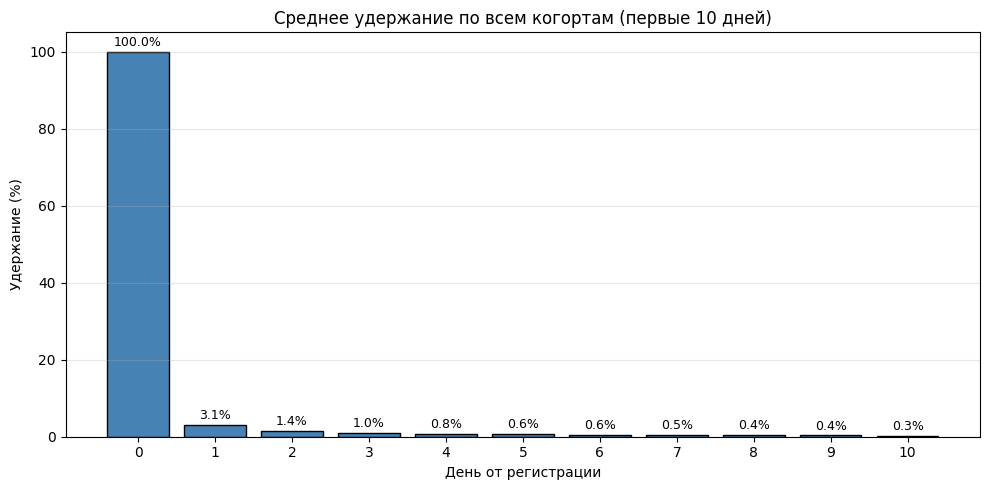

In [35]:
avg_retention = df.groupby('day_number')['retention_rate'].mean().reset_index()
avg_retention_first10 = avg_retention[avg_retention['day_number'] <= 10]

plt.figure(figsize=(10, 5))
plt.bar(avg_retention_first10['day_number'], avg_retention_first10['retention_rate'], 
        color='steelblue', edgecolor='black')
plt.xlabel('День от регистрации')
plt.ylabel('Удержание (%)')
plt.title('Среднее удержание по всем когортам (первые 10 дней)')
plt.xticks(range(0, 11))
plt.ylim(0, 105)

# Подписи значений
for i, row in avg_retention_first10.iterrows():
    plt.text(row['day_number'], row['retention_rate'] + 1.5, 
             f"{row['retention_rate']:.1f}%", ha='center', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Системная проблема и рекомендации

**Наблюдение:** Во всех когортах удержание падает со 100% до ~3-5% на следующий день.

**Это означает, что проблема не в единичном сбое, а в продукте:** пользователи не видят ценности в возвращении.

**Рекомендации:** онбординг, push-уведомления, улучшение first user experience.